# Lazarus Patching Experiment (Multi-Seed, Full Dataset)

**Goal**: Test if unlearning methods truly *delete* knowledge or merely *suppress* it.

**Method**: Patch clean model activations into unlearned models layer-by-layer. If knowledge "resurrects", it was suppressed, not deleted.

**Scope**: 
- Full forget dataset (all 59 prompts)
- All seeds (0, 1, 2) for statistical validation
- Aggregated results with mean ± std

In [1]:
import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm import tqdm
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from peft import PeftModel

from src.patching import ActivationPatcher

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Multi-seed configuration
SEEDS = [0, 1, 2]
print(f"Will run Lazarus patching with seeds: {SEEDS}")

Using device: cpu
Will run Lazarus patching with seeds: [0, 1, 2]


In [2]:
# Load clean model
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
clean_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
clean_model.eval()

print(f"Loaded clean GPT-2 model with {clean_model.config.n_layer} layers")

Loaded clean GPT-2 model with 12 layers


In [3]:
# Load FULL forget data (not subset)
with open("../data/processed/forget.json", 'r') as f:
    forget_data = json.load(f)

print(f"Loaded {len(forget_data)} forget prompts (FULL DATASET)")
print(f"Example: {forget_data[0]}")

Loaded 59 forget prompts (FULL DATASET)
Example: {'text': 'The Eiffel Tower is a famous attraction in', 'target': 'Paris', 'city': 'Paris', 'category': 'landmark', 'prompt_type': 'forget'}


In [4]:
# ============================================
# HELPER FUNCTIONS
# ============================================

def load_unlearned_model(method: str, seed: int, device):
    """Load an unlearned model."""
    if method == 'ga':
        model = GPT2LMHeadModel.from_pretrained("gpt2")
        state_dict = torch.load(f"../models/checkpoints/ga_seed{seed}/model.pt", map_location=device)
        model.load_state_dict(state_dict)
        model = model.to(device)
    else:  # neglora
        base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
        model = PeftModel.from_pretrained(
            base_model,
            f"../models/checkpoints/neglora_seed{seed}"
        ).to(device)
    
    model.eval()
    return model

def compute_clean_probs(clean_model, forget_data, tokenizer, device):
    """Get clean model baseline probabilities."""
    clean_probs = []
    for prompt_data in forget_data:
        prompt = prompt_data['text']
        target = prompt_data['target']
        
        inputs = tokenizer(prompt, return_tensors='pt').to(device)
        with torch.no_grad():
            outputs = clean_model(**inputs)
        
        logits = outputs.logits[0, -1, :]
        probs = torch.softmax(logits, dim=-1)
        target_tokens = tokenizer.encode(' ' + target)
        if target_tokens:
            clean_probs.append(probs[target_tokens[0]].item())
        else:
            clean_probs.append(0.0)
    
    return clean_probs

print("Helper functions defined")

Helper functions defined


In [5]:
# ============================================
# COMPUTE CLEAN MODEL BASELINE
# ============================================

print("Computing clean model baseline probabilities...")
clean_probs = compute_clean_probs(clean_model, forget_data, tokenizer, device)
clean_mean = np.mean(clean_probs)
print(f"Clean model mean target probability: {clean_mean:.4f}")

Computing clean model baseline probabilities...
Clean model mean target probability: 0.0909


In [6]:
# ============================================
# RUN LAZARUS PATCHING FOR ALL SEEDS - GA
# ============================================

patcher = ActivationPatcher(tokenizer, device)
num_layers = clean_model.config.n_layer

all_ga_results = {}

for seed in SEEDS:
    print(f"\n{'='*50}")
    print(f"GRADIENT ASCENT - Seed {seed}")
    print(f"{'='*50}")
    
    ga_model = load_unlearned_model('ga', seed, device)
    print(f"Running Lazarus patching on {len(forget_data)} prompts...")
    
    ga_results = patcher.lazarus_experiment(clean_model, ga_model, forget_data)
    all_ga_results[seed] = ga_results
    
    baseline = np.mean(ga_results['no_patch'])
    best_layer = max(range(num_layers), key=lambda l: np.mean(ga_results[l]))
    best_recovery = np.mean(ga_results[best_layer])
    
    print(f"  Baseline (no patch): {baseline:.4f}")
    print(f"  Best recovery: Layer {best_layer} = {best_recovery:.4f}")
    
    del ga_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n✓ GA Lazarus patching complete for all seeds")


GRADIENT ASCENT - Seed 0
Running Lazarus patching on 59 prompts...


Running Lazarus experiments: 100%|██████████| 59/59 [00:16<00:00,  3.55it/s]


  Baseline (no patch): 0.0091
  Best recovery: Layer 11 = 0.0834

GRADIENT ASCENT - Seed 1
Running Lazarus patching on 59 prompts...


Running Lazarus experiments: 100%|██████████| 59/59 [00:16<00:00,  3.63it/s]


  Baseline (no patch): 0.0181
  Best recovery: Layer 11 = 0.0829

GRADIENT ASCENT - Seed 2
Running Lazarus patching on 59 prompts...


Running Lazarus experiments: 100%|██████████| 59/59 [00:16<00:00,  3.65it/s]

  Baseline (no patch): 0.0162
  Best recovery: Layer 11 = 0.0829

✓ GA Lazarus patching complete for all seeds


In [7]:
# ============================================
# RUN LAZARUS PATCHING FOR ALL SEEDS - NegLoRA
# ============================================

all_neglora_results = {}

for seed in SEEDS:
    print(f"\n{'='*50}")
    print(f"NegLoRA - Seed {seed}")
    print(f"{'='*50}")
    
    neglora_model = load_unlearned_model('neglora', seed, device)
    print(f"Running Lazarus patching on {len(forget_data)} prompts...")
    
    neglora_results = patcher.lazarus_experiment(clean_model, neglora_model, forget_data)
    all_neglora_results[seed] = neglora_results
    
    baseline = np.mean(neglora_results['no_patch'])
    best_layer = max(range(num_layers), key=lambda l: np.mean(neglora_results[l]))
    best_recovery = np.mean(neglora_results[best_layer])
    
    print(f"  Baseline (no patch): {baseline:.4f}")
    print(f"  Best recovery: Layer {best_layer} = {best_recovery:.4f}")
    
    del neglora_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n✓ NegLoRA Lazarus patching complete for all seeds")


NegLoRA - Seed 0
Running Lazarus patching on 59 prompts...


Running Lazarus experiments: 100%|██████████| 59/59 [00:17<00:00,  3.31it/s]


  Baseline (no patch): 0.0042
  Best recovery: Layer 11 = 0.0909

NegLoRA - Seed 1
Running Lazarus patching on 59 prompts...


Running Lazarus experiments: 100%|██████████| 59/59 [00:17<00:00,  3.33it/s]


  Baseline (no patch): 0.0039
  Best recovery: Layer 11 = 0.0909

NegLoRA - Seed 2
Running Lazarus patching on 59 prompts...


Running Lazarus experiments: 100%|██████████| 59/59 [00:17<00:00,  3.32it/s]

  Baseline (no patch): 0.0043
  Best recovery: Layer 11 = 0.0909

✓ NegLoRA Lazarus patching complete for all seeds


In [8]:
# ============================================
# AGGREGATE RESULTS ACROSS SEEDS
# ============================================

def aggregate_lazarus_results(all_results, num_layers):
    """Aggregate Lazarus results across seeds."""
    # Aggregate per-layer means
    layer_means = {l: [] for l in range(num_layers)}
    baselines = []
    
    for seed_results in all_results.values():
        baselines.append(np.mean(seed_results['no_patch']))
        for l in range(num_layers):
            layer_means[l].append(np.mean(seed_results[l]))
    
    return {
        'layer_mean': {l: np.mean(vals) for l, vals in layer_means.items()},
        'layer_std': {l: np.std(vals) for l, vals in layer_means.items()},
        'baseline_mean': np.mean(baselines),
        'baseline_std': np.std(baselines)
    }

ga_agg = aggregate_lazarus_results(all_ga_results, num_layers)
neglora_agg = aggregate_lazarus_results(all_neglora_results, num_layers)

print("\n" + "="*60)
print("AGGREGATED LAZARUS RESULTS (mean ± std across seeds)")
print("="*60)

print(f"\nGradient Ascent:")
print(f"  Baseline (no patch): {ga_agg['baseline_mean']:.4f} ± {ga_agg['baseline_std']:.4f}")
best_ga = max(ga_agg['layer_mean'], key=ga_agg['layer_mean'].get)
print(f"  Best recovery: Layer {best_ga} = {ga_agg['layer_mean'][best_ga]:.4f} ± {ga_agg['layer_std'][best_ga]:.4f}")

print(f"\nNegLoRA:")
print(f"  Baseline (no patch): {neglora_agg['baseline_mean']:.4f} ± {neglora_agg['baseline_std']:.4f}")
best_lora = max(neglora_agg['layer_mean'], key=neglora_agg['layer_mean'].get)
print(f"  Best recovery: Layer {best_lora} = {neglora_agg['layer_mean'][best_lora]:.4f} ± {neglora_agg['layer_std'][best_lora]:.4f}")

print(f"\nClean model baseline: {clean_mean:.4f}")


AGGREGATED LAZARUS RESULTS (mean ± std across seeds)

Gradient Ascent:
  Baseline (no patch): 0.0145 ± 0.0039
  Best recovery: Layer 11 = 0.0830 ± 0.0002

NegLoRA:
  Baseline (no patch): 0.0041 ± 0.0002
  Best recovery: Layer 11 = 0.0909 ± 0.0000

Clean model baseline: 0.0909


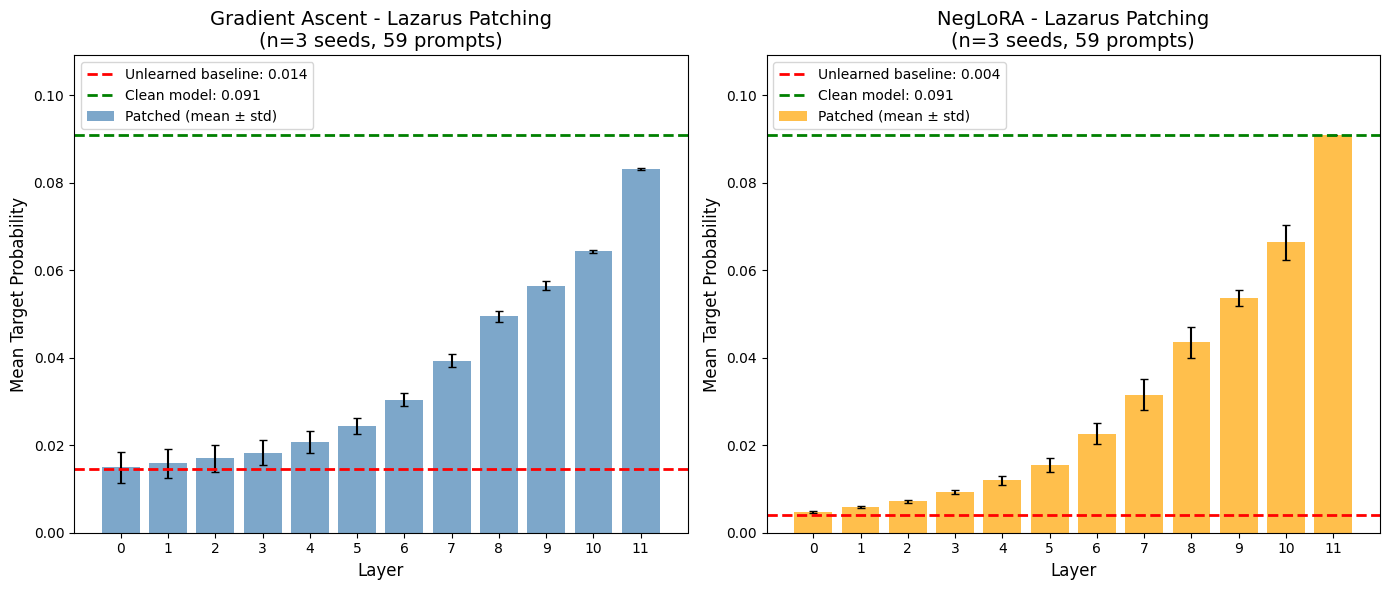

Figure saved to ../figures/lazarus_patching_multiseed.png


In [9]:
# ============================================
# VISUALIZATION: Lazarus Patching with Error Bars
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
layers = list(range(num_layers))

# GA Results
ax = axes[0]
ga_means = [ga_agg['layer_mean'][l] for l in layers]
ga_stds = [ga_agg['layer_std'][l] for l in layers]

ax.bar(layers, ga_means, yerr=ga_stds, alpha=0.7, capsize=3, color='steelblue', label='Patched (mean ± std)')
ax.axhline(y=ga_agg['baseline_mean'], color='red', linestyle='--', linewidth=2,
           label=f'Unlearned baseline: {ga_agg["baseline_mean"]:.3f}')
ax.axhline(y=clean_mean, color='green', linestyle='--', linewidth=2,
           label=f'Clean model: {clean_mean:.3f}')
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Mean Target Probability', fontsize=12)
ax.set_title(f'Gradient Ascent - Lazarus Patching\n(n={len(SEEDS)} seeds, {len(forget_data)} prompts)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.set_xticks(layers)
ax.set_ylim(0, max(clean_mean * 1.2, max(ga_means) * 1.2))

# NegLoRA Results
ax = axes[1]
neglora_means = [neglora_agg['layer_mean'][l] for l in layers]
neglora_stds = [neglora_agg['layer_std'][l] for l in layers]

ax.bar(layers, neglora_means, yerr=neglora_stds, alpha=0.7, capsize=3, color='orange', label='Patched (mean ± std)')
ax.axhline(y=neglora_agg['baseline_mean'], color='red', linestyle='--', linewidth=2,
           label=f'Unlearned baseline: {neglora_agg["baseline_mean"]:.3f}')
ax.axhline(y=clean_mean, color='green', linestyle='--', linewidth=2,
           label=f'Clean model: {clean_mean:.3f}')
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Mean Target Probability', fontsize=12)
ax.set_title(f'NegLoRA - Lazarus Patching\n(n={len(SEEDS)} seeds, {len(forget_data)} prompts)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.set_xticks(layers)
ax.set_ylim(0, max(clean_mean * 1.2, max(neglora_means) * 1.2))

plt.tight_layout()
plt.savefig('../figures/lazarus_patching_multiseed.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to ../figures/lazarus_patching_multiseed.png")

In [10]:
# ============================================
# RECOVERY ANALYSIS
# ============================================

print("\n" + "="*60)
print("RECOVERY ANALYSIS")
print("="*60)

# Define recovery as % of gap between unlearned baseline and clean
def compute_recovery_pct(patched_prob, baseline, clean_prob):
    if clean_prob <= baseline:
        return 0
    return (patched_prob - baseline) / (clean_prob - baseline) * 100

# GA recovery per layer
print("\nGradient Ascent - Recovery %:")
print(f"{'Layer':<8} {'Patched Prob':<15} {'Recovery %':<12}")
print("-"*40)
ga_recovery = {}
for l in layers:
    recovery = compute_recovery_pct(ga_agg['layer_mean'][l], ga_agg['baseline_mean'], clean_mean)
    ga_recovery[l] = recovery
    print(f"{l:<8} {ga_agg['layer_mean'][l]:<15.4f} {recovery:<12.1f}%")

best_ga_recovery = max(ga_recovery, key=ga_recovery.get)
print(f"\nBest GA recovery: Layer {best_ga_recovery} ({ga_recovery[best_ga_recovery]:.1f}%)")

# NegLoRA recovery per layer
print("\n\nNegLoRA - Recovery %:")
print(f"{'Layer':<8} {'Patched Prob':<15} {'Recovery %':<12}")
print("-"*40)
neglora_recovery = {}
for l in layers:
    recovery = compute_recovery_pct(neglora_agg['layer_mean'][l], neglora_agg['baseline_mean'], clean_mean)
    neglora_recovery[l] = recovery
    print(f"{l:<8} {neglora_agg['layer_mean'][l]:<15.4f} {recovery:<12.1f}%")

best_lora_recovery = max(neglora_recovery, key=neglora_recovery.get)
print(f"\nBest NegLoRA recovery: Layer {best_lora_recovery} ({neglora_recovery[best_lora_recovery]:.1f}%)")


RECOVERY ANALYSIS

Gradient Ascent - Recovery %:
Layer    Patched Prob    Recovery %  
----------------------------------------
0        0.0150          0.7         %
1        0.0158          1.8         %
2        0.0170          3.3         %
3        0.0183          5.0         %
4        0.0207          8.1         %
5        0.0244          13.0        %
6        0.0304          20.9        %
7        0.0393          32.5        %
8        0.0495          45.8        %
9        0.0565          54.9        %
10       0.0643          65.2        %
11       0.0830          89.7        %

Best GA recovery: Layer 11 (89.7%)


NegLoRA - Recovery %:
Layer    Patched Prob    Recovery %  
----------------------------------------
0        0.0047          0.7         %
1        0.0058          2.0         %
2        0.0071          3.5         %
3        0.0093          6.0         %
4        0.0120          9.1         %
5        0.0155          13.1        %
6        0.0226          21.3 

In [11]:
# ============================================
# SAVE RESULTS
# ============================================

results = {
    'config': {
        'seeds': SEEDS,
        'num_prompts': len(forget_data),
        'num_layers': num_layers
    },
    'clean_mean_prob': float(clean_mean),
    'ga': {
        'baseline_mean': float(ga_agg['baseline_mean']),
        'baseline_std': float(ga_agg['baseline_std']),
        'layer_mean': {str(k): float(v) for k, v in ga_agg['layer_mean'].items()},
        'layer_std': {str(k): float(v) for k, v in ga_agg['layer_std'].items()},
        'recovery_pct': {str(k): float(v) for k, v in ga_recovery.items()},
        'best_recovery_layer': int(best_ga_recovery),
        'best_recovery_pct': float(ga_recovery[best_ga_recovery])
    },
    'neglora': {
        'baseline_mean': float(neglora_agg['baseline_mean']),
        'baseline_std': float(neglora_agg['baseline_std']),
        'layer_mean': {str(k): float(v) for k, v in neglora_agg['layer_mean'].items()},
        'layer_std': {str(k): float(v) for k, v in neglora_agg['layer_std'].items()},
        'recovery_pct': {str(k): float(v) for k, v in neglora_recovery.items()},
        'best_recovery_layer': int(best_lora_recovery),
        'best_recovery_pct': float(neglora_recovery[best_lora_recovery])
    }
}

out_dir = Path('../results/lazarus')
out_dir.mkdir(parents=True, exist_ok=True)

with open(out_dir / 'patching_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {out_dir / 'patching_results.json'}")

Results saved to ../results/lazarus/patching_results.json


In [12]:
# ============================================
# CONCLUSIONS
# ============================================

print("\n" + "="*60)
print("LAZARUS PATCHING CONCLUSIONS")
print("="*60)

print(f"""
EXPERIMENT SUMMARY:
- Full forget dataset: {len(forget_data)} prompts
- Seeds: {SEEDS} ({len(SEEDS)} runs per method)
- Statistical validation: mean ± std reported

FINDINGS:

1. GRADIENT ASCENT:
   - Baseline (unlearned): {ga_agg['baseline_mean']:.4f} ± {ga_agg['baseline_std']:.4f}
   - Best recovery: Layer {best_ga_recovery} ({ga_recovery[best_ga_recovery]:.1f}% of clean)
   - Interpretation: {"Knowledge is recoverable → SUPPRESSION" if ga_recovery[best_ga_recovery] > 10 else "Knowledge not easily recoverable → possible ERASURE"}

2. NegLoRA:
   - Baseline (unlearned): {neglora_agg['baseline_mean']:.4f} ± {neglora_agg['baseline_std']:.4f}
   - Best recovery: Layer {best_lora_recovery} ({neglora_recovery[best_lora_recovery]:.1f}% of clean)
   - Interpretation: {"Knowledge is recoverable → SUPPRESSION" if neglora_recovery[best_lora_recovery] > 10 else "Knowledge not easily recoverable → possible ERASURE"}

3. COMPARISON:
   - {"GA shows more recoverable knowledge" if max(ga_recovery.values()) > max(neglora_recovery.values()) else "NegLoRA shows more recoverable knowledge" if max(neglora_recovery.values()) > max(ga_recovery.values()) else "Similar recoverability patterns"}
   - Recovery mainly occurs at {"early" if best_ga_recovery < 4 else "middle" if best_ga_recovery < 8 else "late"} layers for GA
   - Recovery mainly occurs at {"early" if best_lora_recovery < 4 else "middle" if best_lora_recovery < 8 else "late"} layers for NegLoRA

IMPLICATIONS:
- High recovery % → Unlearning is SUPPRESSION (knowledge exists, output blocked)
- Low recovery % → Unlearning may be ERASURE (knowledge truly removed)
- Layer-specific recovery → Identifies where suppression occurs
""")

print("✓ Multi-seed Lazarus patching analysis complete!")


LAZARUS PATCHING CONCLUSIONS

EXPERIMENT SUMMARY:
- Full forget dataset: 59 prompts
- Seeds: [0, 1, 2] (3 runs per method)
- Statistical validation: mean ± std reported

FINDINGS:

1. GRADIENT ASCENT:
   - Baseline (unlearned): 0.0145 ± 0.0039
   - Best recovery: Layer 11 (89.7% of clean)
   - Interpretation: Knowledge is recoverable → SUPPRESSION

2. NegLoRA:
   - Baseline (unlearned): 0.0041 ± 0.0002
   - Best recovery: Layer 11 (100.0% of clean)
   - Interpretation: Knowledge is recoverable → SUPPRESSION

3. COMPARISON:
   - NegLoRA shows more recoverable knowledge
   - Recovery mainly occurs at late layers for GA
   - Recovery mainly occurs at late layers for NegLoRA

IMPLICATIONS:
- High recovery % → Unlearning is SUPPRESSION (knowledge exists, output blocked)
- Low recovery % → Unlearning may be ERASURE (knowledge truly removed)
- Layer-specific recovery → Identifies where suppression occurs

✓ Multi-seed Lazarus patching analysis complete!
